# Modal Peak-Count Geometry Debug (Precursor m/z Coloring)

This notebook isolates spectra with the **most common number of valid peaks**
in `massspec_train`, then explores their embedding geometry with PCA and UMAP,
colored by precursor m/z.

Goal: remove peak-count heterogeneity and inspect geometry within a fixed-length subset.

In [1]:
import os
import sys

os.chdir(
    os.path.join(
        os.path.dirname(os.getcwd())
        if os.path.basename(os.getcwd()) == "notebooks"
        else os.getcwd()
    )
)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

Working directory: /home/wuhao/spectra-learning


In [2]:
# Configuration
CHECKPOINT_DIR = "experiments/tune_jepa_sigreg_global_14/trial_000"
CONFIG_PATH = "configs/gems_a_50_mask.py"
DEVICE = "cuda"
SEED = 42

UMAP_NEIGHBORS = 30
UMAP_MIN_DIST = 0.3

In [3]:
import logging
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA
import umap
from tqdm.auto import tqdm

from utils.training import (
    load_config,
    build_model_from_config,
    load_pretrained_weights,
    latest_ckpt_path,
)
from input_pipeline import TfLightningDataModule
from train import _iter_massspec_probe

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
np.random.seed(SEED)
torch.manual_seed(SEED)

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-02-13 16:12:24.852172: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 16:12:24.886292: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-13 16:12:25.819325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load DataModule and Frozen Backbone

In [4]:
config = load_config(CONFIG_PATH)
datamodule = TfLightningDataModule(config, seed=int(config.seed))

config.num_peaks = datamodule.info["num_peaks"]
config.fingerprint_bits = int(datamodule.info["fingerprint_bits"])

model = build_model_from_config(config)
ckpt_path = latest_ckpt_path(Path(CHECKPOINT_DIR))
print(f"Loading checkpoint: {ckpt_path}")
load_pretrained_weights(model, ckpt_path)

device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()
for p in model.parameters():
    p.requires_grad = False

print(f"Model on {device}, params={sum(p.numel() for p in model.parameters()):,}")
print(f"pooling_type={config.pooling_type}, num_peaks cap={config.num_peaks}")
print(f"massspec_train size={datamodule.info['massspec_train_size']:,}")

INFO:input_pipeline:Found existing TFRecords at /home/wuhao/spectra-learning/data/gems_peaklist_tfrecord


Loading checkpoint: experiments/tune_jepa_sigreg_global_14/trial_000/checkpoints/last.ckpt


Model on cuda, params=12,525,056
pooling_type=pma, num_peaks cap=60
massspec_train size=194,119


## 2. Find The Most Common Valid-Peak Count

0it [00:00, ?it/s]

2026-02-13 16:12:28.052569: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


1it [00:07,  7.73s/it]

23it [00:07,  4.11it/s]

45it [00:07,  9.55it/s]

...

334it [00:09, 183.87it/s]

354it [00:09, 168.45it/s]

376it [00:09, 180.89it/s]

2026-02-13 16:12:37.304058: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
380it [00:09, 39.28it/s] 

Most common n_valid_peaks = 60
Samples with that count = 25,492 (13.13%)
Top 15 peak-count frequencies:
  peaks=60  count= 25492  (13.13%)
  peaks= 2  count=  8473  ( 4.36%)
  peaks= 3  count=  7730  ( 3.98%)
  peaks= 4  count=  7208  ( 3.71%)
  peaks= 5  count=  7002  ( 3.61%)
  peaks= 1  count=  6775  ( 3.49%)
  peaks= 6  count=  6747  ( 3.48%)
  peaks= 7  count=  6346  ( 3.27%)
  peaks= 8  count=  6283  ( 3.24%)
  peaks= 9  count=  5612  ( 2.89%)
  peaks=10  count=  5434  ( 2.80%)
  peaks=11  count=  5075  ( 2.61%)
  peaks=12  count=  4932  ( 2.54%)
  peaks=13  count=  4739  ( 2.44%)
  peaks=14  count=  4656  ( 2.40%)


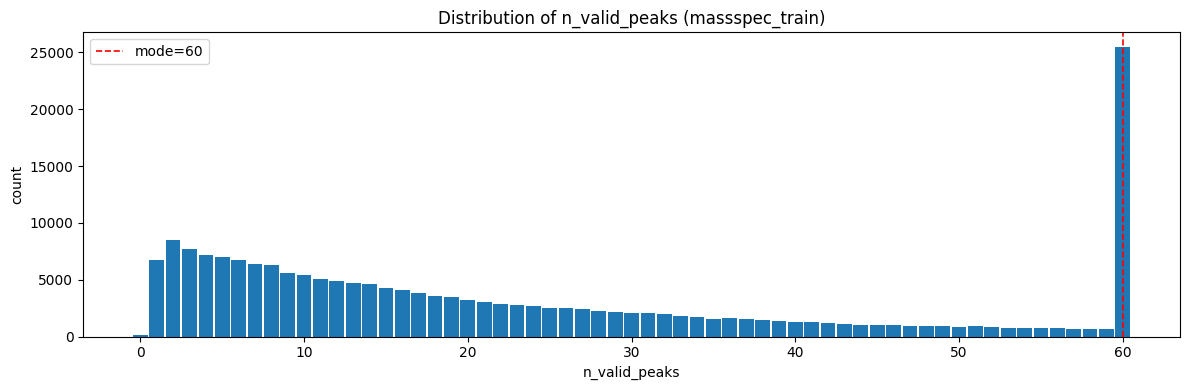

In [5]:
peak_count_counter = Counter()

for batch in tqdm(
    _iter_massspec_probe(
        datamodule,
        "massspec_train",
        seed=SEED,
        peak_ordering=str(config.peak_ordering),
        drop_remainder=False,
    )
):
    n_valid = batch["peak_valid_mask"].sum(dim=1).cpu().numpy().tolist()
    peak_count_counter.update(n_valid)

mode_peak_count, mode_count = peak_count_counter.most_common(1)[0]
total_samples = sum(peak_count_counter.values())

print(f"Most common n_valid_peaks = {mode_peak_count}")
print(
    f"Samples with that count = {mode_count:,} ({mode_count / total_samples * 100:.2f}%)"
)

print("Top 15 peak-count frequencies:")
for k, c in peak_count_counter.most_common(15):
    print(f"  peaks={k:2d}  count={c:6d}  ({c / total_samples * 100:5.2f}%)")

vals = np.array(sorted(peak_count_counter.keys()))
cnts = np.array([peak_count_counter[v] for v in vals])

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vals, cnts, width=0.9, edgecolor="none")
ax.axvline(
    mode_peak_count,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"mode={mode_peak_count}",
)
ax.set_title("Distribution of n_valid_peaks (massspec_train)")
ax.set_xlabel("n_valid_peaks")
ax.set_ylabel("count")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Extract Embeddings Only For Modal Peak-Count Subset

In [6]:
subset_embeds = []
subset_precursor_mz = []
subset_precursor_mz_da = []

print(f"Extracting only samples with n_valid_peaks == {mode_peak_count} ...")
with torch.no_grad():
    for batch in tqdm(
        _iter_massspec_probe(
            datamodule,
            "massspec_train",
            seed=SEED,
            peak_ordering=str(config.peak_ordering),
            drop_remainder=False,
        )
    ):
        n_valid = batch["peak_valid_mask"].sum(dim=1)
        keep_cpu = n_valid == mode_peak_count

        if keep_cpu.any():
            batch_dev = {k: v.to(device) for k, v in batch.items()}
            embeddings = model.encoder(
                batch_dev["peak_mz"],
                batch_dev["peak_intensity"],
                valid_mask=batch_dev["peak_valid_mask"],
            )
            pooled = model.pool(embeddings, batch_dev["peak_valid_mask"])

            keep_dev = keep_cpu.to(device)
            subset_embeds.append(pooled[keep_dev].cpu().float())
            subset_precursor_mz.append(
                batch["precursor_mz"][keep_cpu].to(torch.float32)
            )
            subset_precursor_mz_da.append(
                batch["precursor_mz"][keep_cpu].to(torch.float32)
                * float(config.max_precursor_mz)
            )

X = torch.cat(subset_embeds, dim=0).numpy()
prec_mz = torch.cat(subset_precursor_mz).numpy()
prec_mz_da = torch.cat(subset_precursor_mz_da).numpy()

print(f"Subset embedding shape: {X.shape} ({X.nbytes / 1e6:.1f} MB)")
print(
    f"Precursor m/z (Da): min={prec_mz_da.min():.1f}, median={np.median(prec_mz_da):.1f}, max={prec_mz_da.max():.1f}"
)

Extracting only samples with n_valid_peaks == 60 ...


0it [00:00, ?it/s]

1it [00:08,  8.36s/it]

3it [00:08,  2.21s/it]

5it [00:08,  1.10s/it]

...

375it [00:30, 17.07it/s]

377it [00:30, 17.21it/s]

379it [00:30, 17.11it/s]

2026-02-13 16:13:08.532085: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
380it [00:31, 12.21it/s]

Subset embedding shape: (25492, 256) (26.1 MB)
Precursor m/z (Da): min=97.0, median=395.2, max=999.4


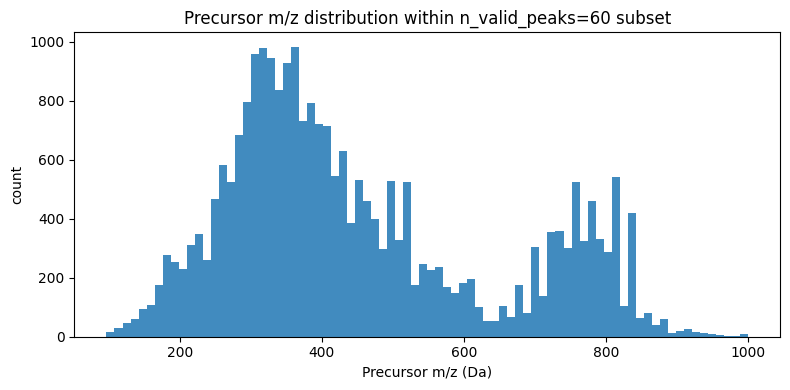

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prec_mz_da, bins=80, edgecolor="none", alpha=0.85)
ax.set_title(
    f"Precursor m/z distribution within n_valid_peaks={mode_peak_count} subset"
)
ax.set_xlabel("Precursor m/z (Da)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 4. PCA Geometry (Colored by Precursor m/z)

Components for 90% variance: 7
Components for 95% variance: 9


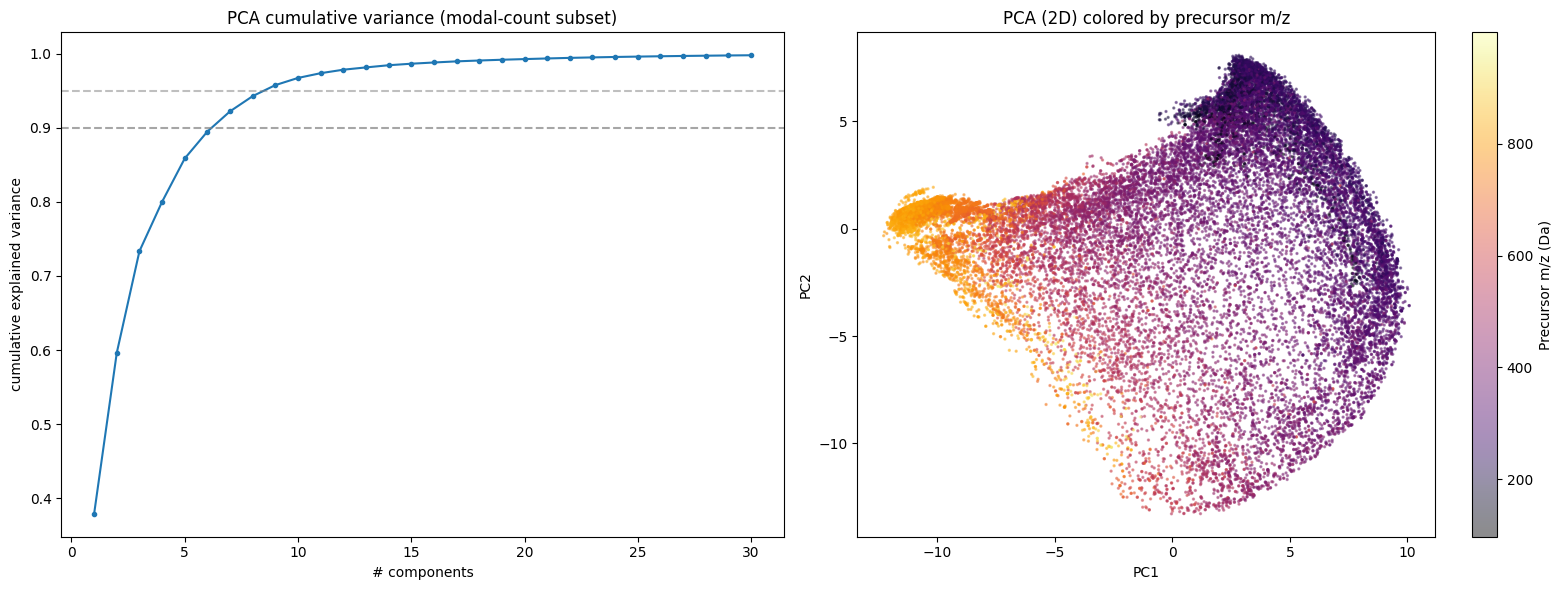

In [8]:
pca_full = PCA(n_components=min(30, X.shape[1]))
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(cumvar, 0.90)) + 1
n95 = int(np.searchsorted(cumvar, 0.95)) + 1

print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")

coords_pca = PCA(n_components=2).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(np.arange(1, len(cumvar) + 1), cumvar, marker="o", markersize=3)
axes[0].axhline(0.90, color="gray", linestyle="--", alpha=0.7)
axes[0].axhline(0.95, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("PCA cumulative variance (modal-count subset)")
axes[0].set_xlabel("# components")
axes[0].set_ylabel("cumulative explained variance")

sc = axes[1].scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=prec_mz_da,
    cmap="inferno",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
axes[1].set_title("PCA (2D) colored by precursor m/z")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[1], label="Precursor m/z (Da)")

plt.tight_layout()
plt.show()

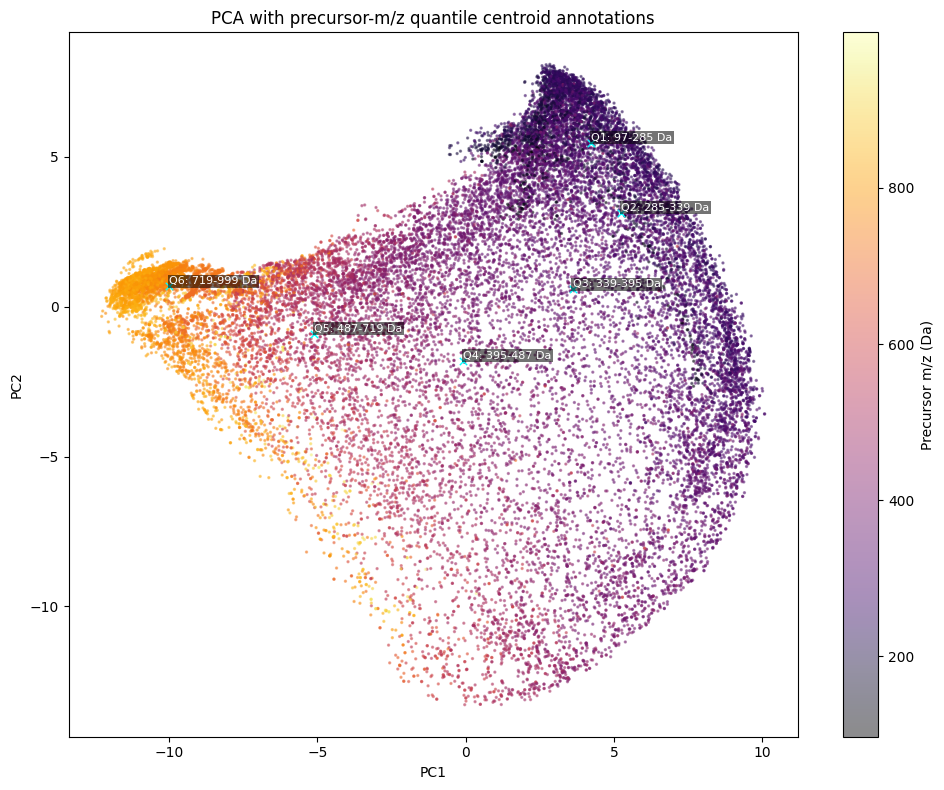

In [9]:
def annotate_precursor_quantiles(ax, coords, precursor_da, n_bins=6):
    edges = np.quantile(precursor_da, np.linspace(0, 1, n_bins + 1))
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i == n_bins - 1:
            mask = (precursor_da >= lo) & (precursor_da <= hi)
        else:
            mask = (precursor_da >= lo) & (precursor_da < hi)
        x = np.median(coords[mask, 0])
        y = np.median(coords[mask, 1])
        ax.scatter([x], [y], c="cyan", s=28, marker="x", linewidths=1.0)
        ax.text(
            x,
            y,
            f"Q{i + 1}: {lo:.0f}-{hi:.0f} Da",
            fontsize=8,
            color="white",
            ha="left",
            va="bottom",
            bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=1.0),
        )


fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    coords_pca[:, 0],
    coords_pca[:, 1],
    c=prec_mz_da,
    cmap="inferno",
    s=2.0,
    alpha=0.45,
    rasterized=True,
)
annotate_precursor_quantiles(ax, coords_pca, prec_mz_da, n_bins=6)
ax.set_title("PCA with precursor-m/z quantile centroid annotations")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(sc, ax=ax, label="Precursor m/z (Da)")
plt.tight_layout()
plt.show()

## 5. UMAP Geometry (Colored by Precursor m/z)

In [10]:
print(
    f"Running UMAP on {X.shape[0]:,} samples with fixed n_valid_peaks={mode_peak_count} ..."
)
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="cosine",
    random_state=SEED,
)
coords_umap = reducer.fit_transform(X)
print(f"UMAP output shape: {coords_umap.shape}")

Running UMAP on 25,492 samples with fixed n_valid_peaks=60 ...


UMAP output shape: (25492, 2)


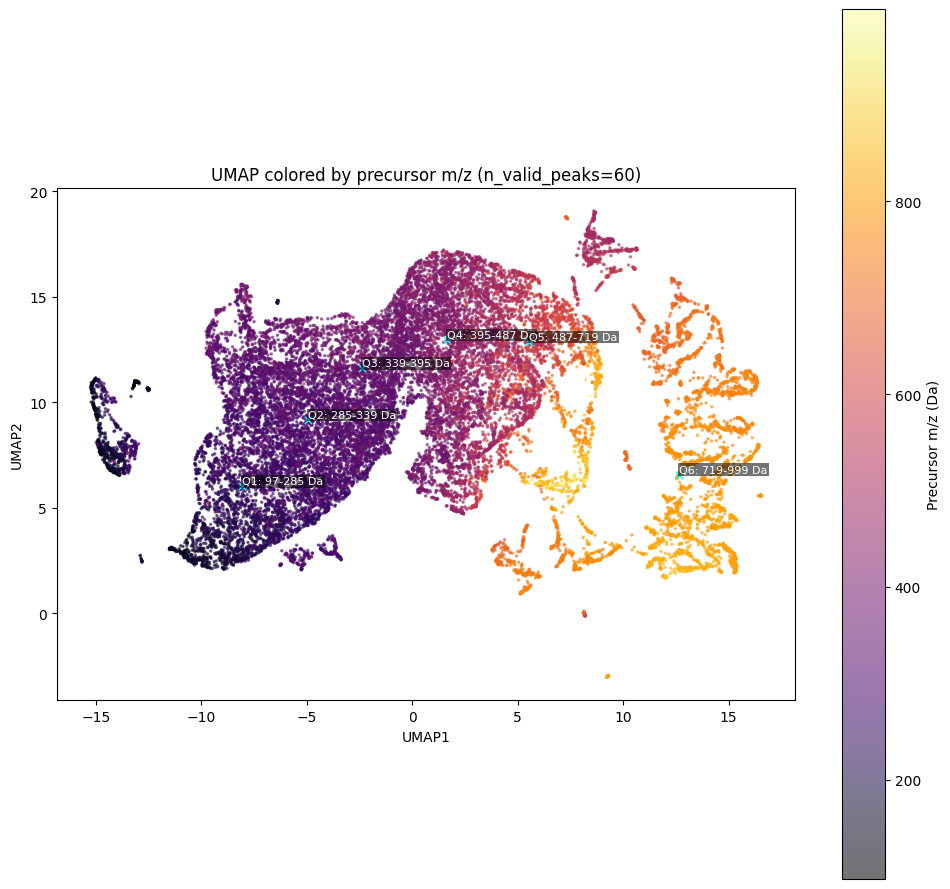

In [11]:
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    coords_umap[:, 0],
    coords_umap[:, 1],
    c=prec_mz_da,
    cmap="inferno",
    s=2.3,
    alpha=0.55,
    rasterized=True,
)
annotate_precursor_quantiles(ax, coords_umap, prec_mz_da, n_bins=6)
ax.set_title(f"UMAP colored by precursor m/z (n_valid_peaks={mode_peak_count})")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_aspect("equal")
plt.colorbar(sc, ax=ax, label="Precursor m/z (Da)")
plt.tight_layout()
plt.show()

## 6. Simple Numeric Summary

In [12]:
def corr(a, b):
    return float(np.corrcoef(a, b)[0, 1])


print("Correlations with precursor m/z (Da):")
print(f"  PCA PC1:  {corr(coords_pca[:, 0], prec_mz_da): .4f}")
print(f"  PCA PC2:  {corr(coords_pca[:, 1], prec_mz_da): .4f}")
print(f"  UMAP 1:   {corr(coords_umap[:, 0], prec_mz_da): .4f}")
print(f"  UMAP 2:   {corr(coords_umap[:, 1], prec_mz_da): .4f}")

Correlations with precursor m/z (Da):
  PCA PC1:  -0.8787
  PCA PC2:  -0.2960
  UMAP 1:    0.9168
  UMAP 2:   -0.0015


Interpretation guide:
- Because all samples share the same `n_valid_peaks`, remaining structure should less strongly reflect sparsity/length effects.
- Any clear gradients now are more likely tied to precursor m/z or other chemistry-related factors rather than token-count strata.